# CVaR Optimization

This notebook solves a **mean-CVaR** (Conditional Value-at-Risk) allocation
problem on a small ETF universe. CVaR directly targets tail losses rather than
variance, making it well-suited for portfolios where downside risk matters most.

We compare the CVaR frontier against the classical mean-variance frontier.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyvallocation import PortfolioWrapper

## Load ETF return scenarios

We use the most recent 750 trading days from the bundled ETF dataset.

In [2]:
from pathlib import Path

_candidates = [
    Path("examples/ETF_prices.csv"),
    Path("../examples/ETF_prices.csv"),
    Path("../../examples/ETF_prices.csv"),
    Path("../../../examples/ETF_prices.csv"),
]
_csv = next((p for p in _candidates if p.exists()), None)
if _csv is None:
    raise FileNotFoundError("ETF_prices.csv not found")
prices = pd.read_csv(_csv, index_col="Date", parse_dates=True)
prices = prices.dropna(how="all").ffill()
returns = prices.pct_change().dropna(how="any").iloc[-750:]

probabilities = np.full(len(returns), 1.0 / len(returns))

print(f"Assets : {list(returns.columns)}")
print(f"Scenarios: {len(returns)}")

Assets : ['DBC', 'GLD', 'SPY', 'TLT']
Scenarios: 750


## Build the CVaR frontier

We use `from_scenarios` with uniform probabilities and trace a 7-point
CVaR frontier at the 5% tail level.

In [3]:
wrapper = PortfolioWrapper.from_scenarios(
    returns, probabilities=probabilities
)

cvar_frontier = wrapper.cvar_frontier(num_portfolios=7, alpha=0.05)

Estimating mu and cov from scenarios (no explicit values provided).


## Extract the minimum-CVaR portfolio

In [4]:
min_w, min_ret, min_cvar = cvar_frontier.min_risk()

print("=== Minimum-CVaR Portfolio ===")
print(min_w.round(4))
print(f"Expected return: {min_ret:.4%}")
print(f"CVaR (alpha=5%):  {min_cvar:.4%}")

=== Minimum-CVaR Portfolio ===
DBC    0.1453
GLD    0.3338
SPY    0.2218
TLT    0.2991
Name: Min Risk Portfolio, dtype: float64
Expected return: 0.0306%
CVaR (alpha=5%):  1.4032%


## Compare CVaR vs mean-variance frontiers

We overlay both frontiers. The MV frontier uses volatility as the risk axis,
while the CVaR frontier uses CVaR; here we plot them side by side for visual
comparison of the return-risk trade-off.

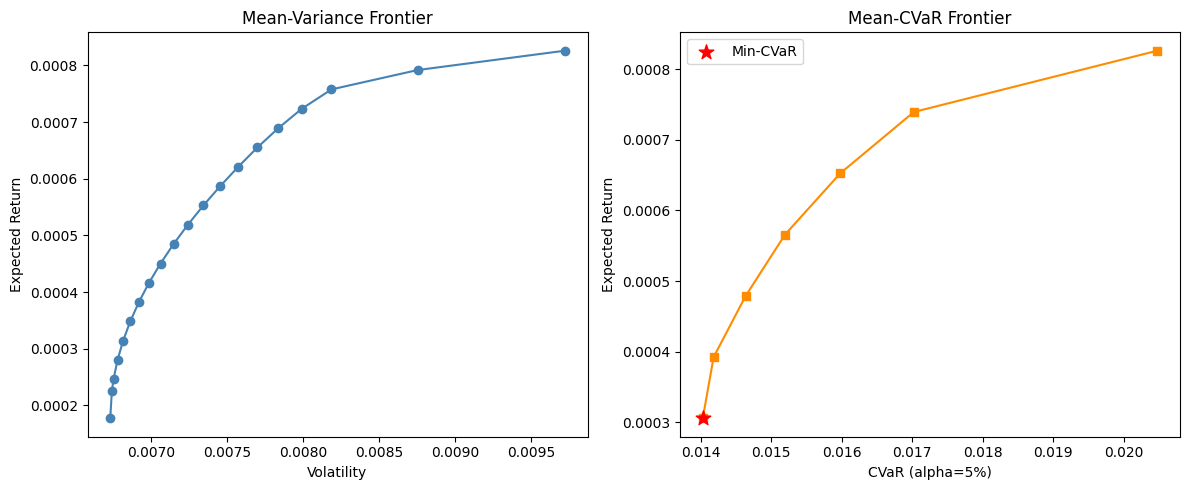

In [5]:
mv_frontier = wrapper.variance_frontier(num_portfolios=20)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Mean-Variance
axes[0].plot(mv_frontier.risks, mv_frontier.returns, "o-", color="steelblue")
axes[0].set_xlabel("Volatility")
axes[0].set_ylabel("Expected Return")
axes[0].set_title("Mean-Variance Frontier")

# Right: Mean-CVaR
axes[1].plot(cvar_frontier.risks, cvar_frontier.returns, "s-", color="darkorange")
axes[1].scatter(min_cvar, min_ret, s=120, marker="*",
                color="red", zorder=5, label="Min-CVaR")
axes[1].set_xlabel("CVaR (alpha=5%)")
axes[1].set_ylabel("Expected Return")
axes[1].set_title("Mean-CVaR Frontier")
axes[1].legend()

fig.tight_layout()
plt.show()